# Background Differences in AI-Assisted Learning Behavior


## Overview

This notebook examines whether AI-use behavior differs across student background strata and whether those behavioral differences help explain score differences. It builds a student-level table by merging randomized group assignment, background survey variables, prior-knowledge scores, exam scores, and observed behavior profiles.

The analysis compares behavior composition, behavior-adjusted score gradients, and experimental-control score differences across University ranking and Prior knowledge strata. The main outputs are the inequality and behavior-composition figures used to interpret whether proactive and critical AI use is distributed unevenly across backgrounds.


## Setup

This block imports reusable loaders, parsers, regression helpers, and plotting functions. The notebook performs the merge and modeling steps directly, while helper functions handle repeated file parsing, behavior labeling, and chart formatting.


In [1]:
from pathlib import Path
import sys
import warnings
import matplotlib.pyplot as plt

# Suppress display-only warnings so notebook output stays focused on the analysis results.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout")
# Clear figures left open by previous interactive runs before saving new PDFs.
plt.close("all")


def _find_repo_root():
    """Find the repository root from either Jupyter or the test runner."""
    # The working directory may be the repository root or a nested directory.
    # Walking upward makes path resolution stable across both cases.
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "analyze").exists():
            return candidate
    raise RuntimeError("Could not locate repository root.")


def _data_path(*candidates):
    """Return the first existing path across current and legacy data layouts."""
    # Some source files have old EduAnalyze paths; fallbacks keep the notebook portable.
    for candidate in candidates:
        path = Path(candidate)
        if not path.is_absolute():
            path = REPO_ROOT / path
        if path.exists():
            return path
    return REPO_ROOT / candidates[0]


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Figures are written here unless the automated test runner redirects them.
FIGURES_DIR = REPO_ROOT / "figures"
SHOW_FIGURES = True
print("Repository:", ".")
print("Figures:", "figures")


Repository: .
Figures: figures


In [2]:
import pandas as pd

from analyze.config import (
    MATH_HW1_PROBLEMS,
    MATH_HW2_PROBLEMS,
    MATH_SCORE_FILE,
    MATH_SCORE_MAP,
    PRESURVEY_FILE,
    PYTHON_SCORE_FILE,
    VALIDUSER_FILE,
)
from analyze.core import (
    load_capability_scores,
    load_homework_scores,
    load_presurvey_data,
    load_valid_users,
    merge_presurvey_to_df,
    prepare_covariates,
)
import analyze.stats.regression as regression_stats
import analyze.background.strata as strata
import analyze.visualization.inequality_plots as inequality_plots

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Build the Student-Level Analysis Table

This block creates one row per participant with group assignment, background variables, prior knowledge, and exam score. The randomized roster is merged with presurvey data, capability scores, and homework/exam scores. University ranking and capability score are then converted into categorical strata.

The output is the shared analysis table used by the behavior-composition, score-gradient, and experimental-control comparisons.


In [3]:
# 1. Randomized participant roster, split by course.
# The group field distinguishes control from experimental access.
python_df, math_df = load_valid_users(VALIDUSER_FILE)

# 2. Background variables from the presurvey.
# These include university ranking and other demographic/academic fields.
presurvey = load_presurvey_data(PRESURVEY_FILE)
python_df = merge_presurvey_to_df(python_df, presurvey, "python")
math_df = merge_presurvey_to_df(math_df, presurvey, "math")

# 3. Prior knowledge from the capability/pretest score files.
# Capability is later binned into Low/Mid/High within each course.
py_captest, math_captest = load_capability_scores(REPO_ROOT / "data/annotation/captest_scores.json")
python_df = python_df.merge(py_captest, on="username", how="left")
math_df = math_df.merge(math_captest, on="username", how="left")

# 4. Assignment and exam scores.
# The downstream models use hw2_score as the exam outcome.
py_homework, math_homework = load_homework_scores(
    py_scores_file=PYTHON_SCORE_FILE,
    math_scores_file=MATH_SCORE_FILE,
    math_hw1_problems=MATH_HW1_PROBLEMS,
    math_hw2_problems=MATH_HW2_PROBLEMS,
    math_score_map=MATH_SCORE_MAP,
)
python_df = python_df.merge(py_homework, on="username", how="left")
math_df = math_df.merge(math_homework, on="username", how="left")

# 5. Normalize covariates and create the two background strata.
# We keep both numeric values for regression and labels for grouped summaries.
python_df = prepare_covariates(python_df, "python")
math_df = prepare_covariates(math_df, "math")
python_df["university_cat"] = python_df["university_ranking_num"].apply(strata.normalize_university_ranking_from_num)
math_df["university_cat"] = math_df["university_ranking_num"].apply(strata.normalize_university_ranking_from_num)
python_df["capability_cat"] = python_df["captest_score"].apply(lambda x: strata.categorize_capability_from_score(x, "python"))
math_df["capability_cat"] = math_df["captest_score"].apply(lambda x: strata.categorize_capability_from_score(x, "math"))

print("Python rows:", len(python_df), "Game Theory rows:", len(math_df))
python_df[["username", "group", "university_cat", "capability_cat", "hw2_score"]].head()



Loading valid users...
  Loaded 81 Python users and 237 Math users
    Python - Treatment: 54, Control: 27
    Math - Treatment: 158, Control: 79

Loading presurvey data...
  Loaded presurvey data for 318 users

Merging presurvey data for python...
  Merged presurvey data for 81 python users

Merging presurvey data for math...
  Merged presurvey data for 237 math users

Loading capability scores...
  Loaded captest for 80 Python users and 237 Math users

Loading homework scores...
  Loaded homework scores for 81 Python users and 237 Math users

Preparing covariates for python...
  Major classification: {'CS': 36, 'EE': 16, 'Other Engineering': 15, 'Math & Stat': 6, 'Natural Science': 3, 'Business': 2, 'Humanities': 2, 'Applied Science': 1}
  Prepared covariates for 81 python users

Preparing covariates for math...
  Major classification: {'Humanities': 55, 'CS': 48, 'Other Engineering': 40, 'EE': 35, 'Business': 19, 'Unknown': 15, 'Math & Stat': 14, 'Applied Science': 6, 'Natural Scie

,username,group,university_cat,capability_cat,hw2_score
0,llm4edu-py-ypSsqwqCgZbJPMYAOJeB,0,High,Mid,11.000000
1,llm4edu-py-BHU84uyjzsxSwcvbFJck,0,High,High,8.000000
2,llm4edu-py-ukxHjLj9PAfBGSsRWtMM,0,High,Mid,8.000000
3,llm4edu-py-WTzivqKMTSQUtWy7qtDg,0,High,High,3.047619
4,llm4edu-py-DbLk_EA9PnbMb7kqaZWc,0,High,High,1.000000


## Behavior Composition by Background

This block estimates how behavior profiles are distributed within each background stratum. Student-level behavior labels are attached to experimental participants and then grouped by university ranking and prior knowledge.

The printed statistics quantify whether higher background strata are associated with a greater probability of proactive and critical AI use.


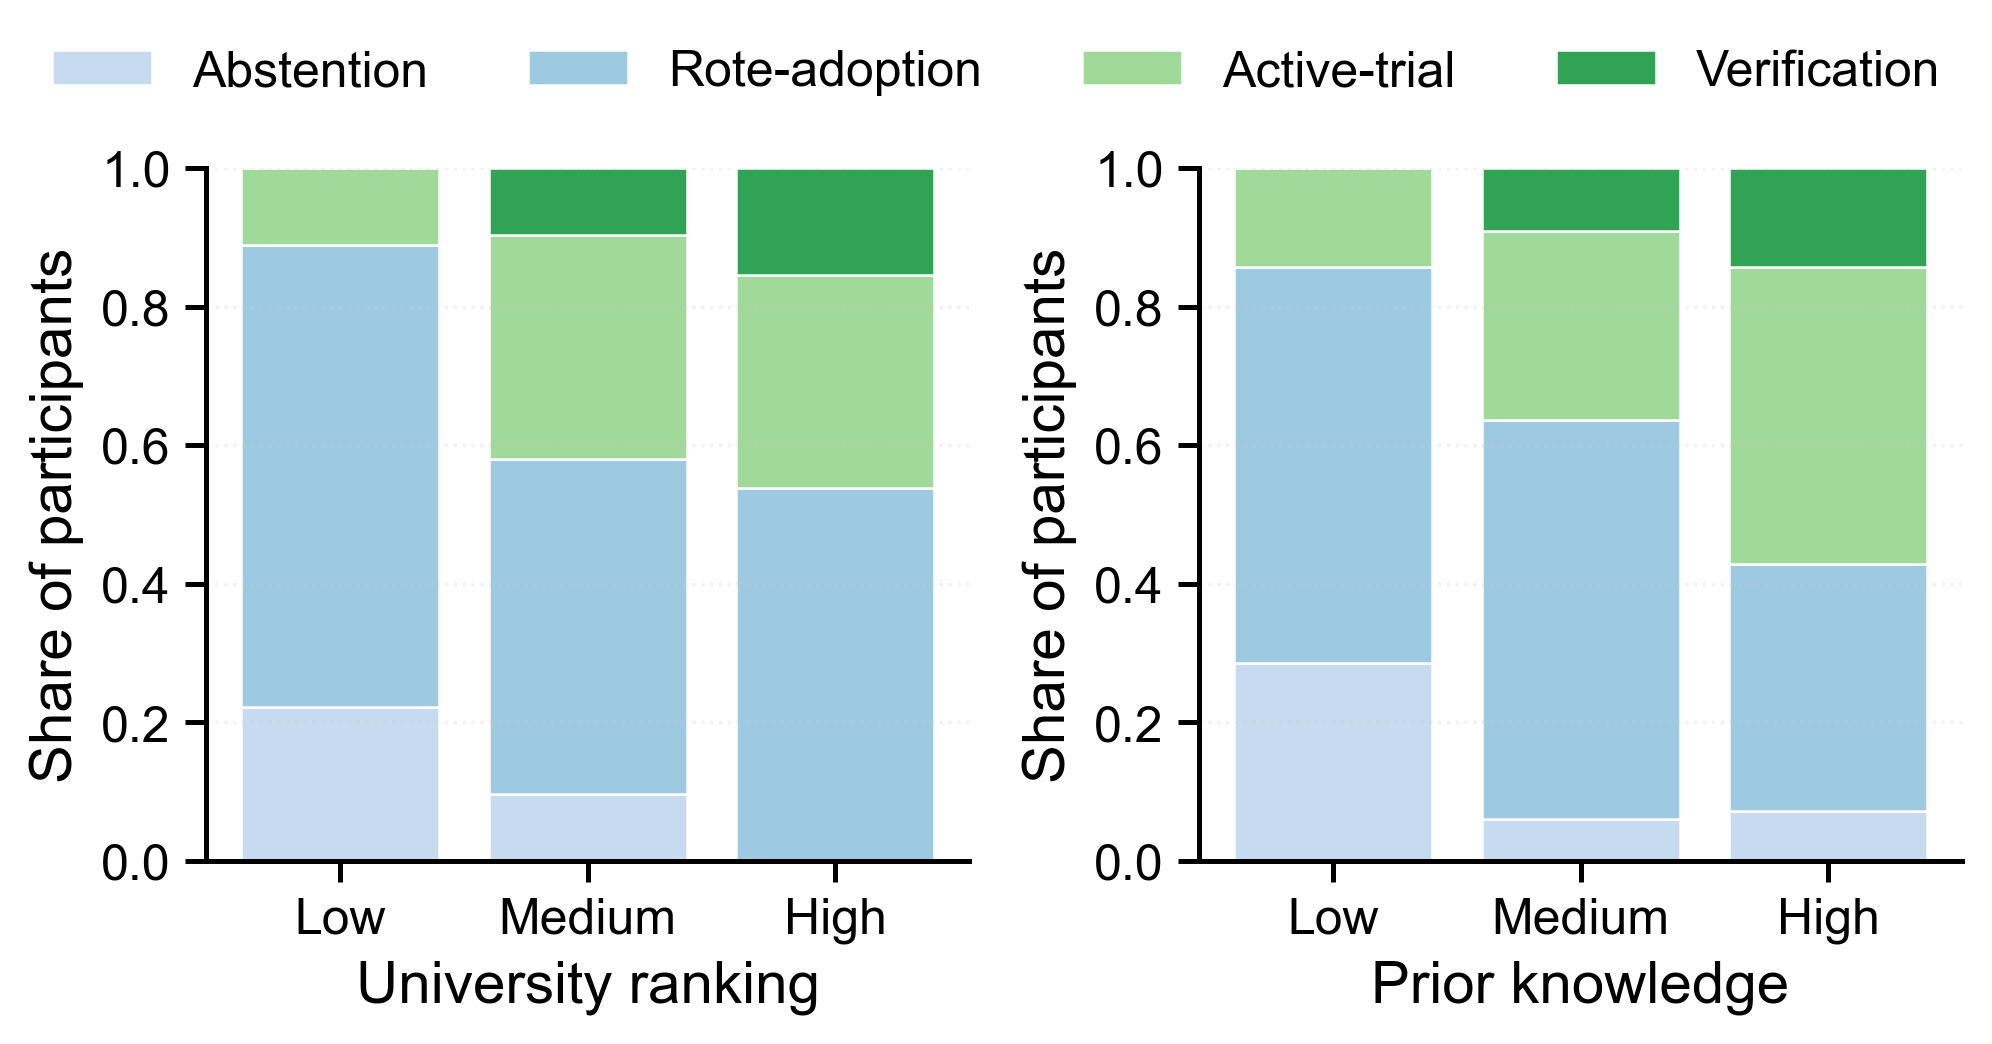

[A1 behavior] Saved behavior-group proportions plot to: a1_behavior_group_proportions_python_exp.pdf


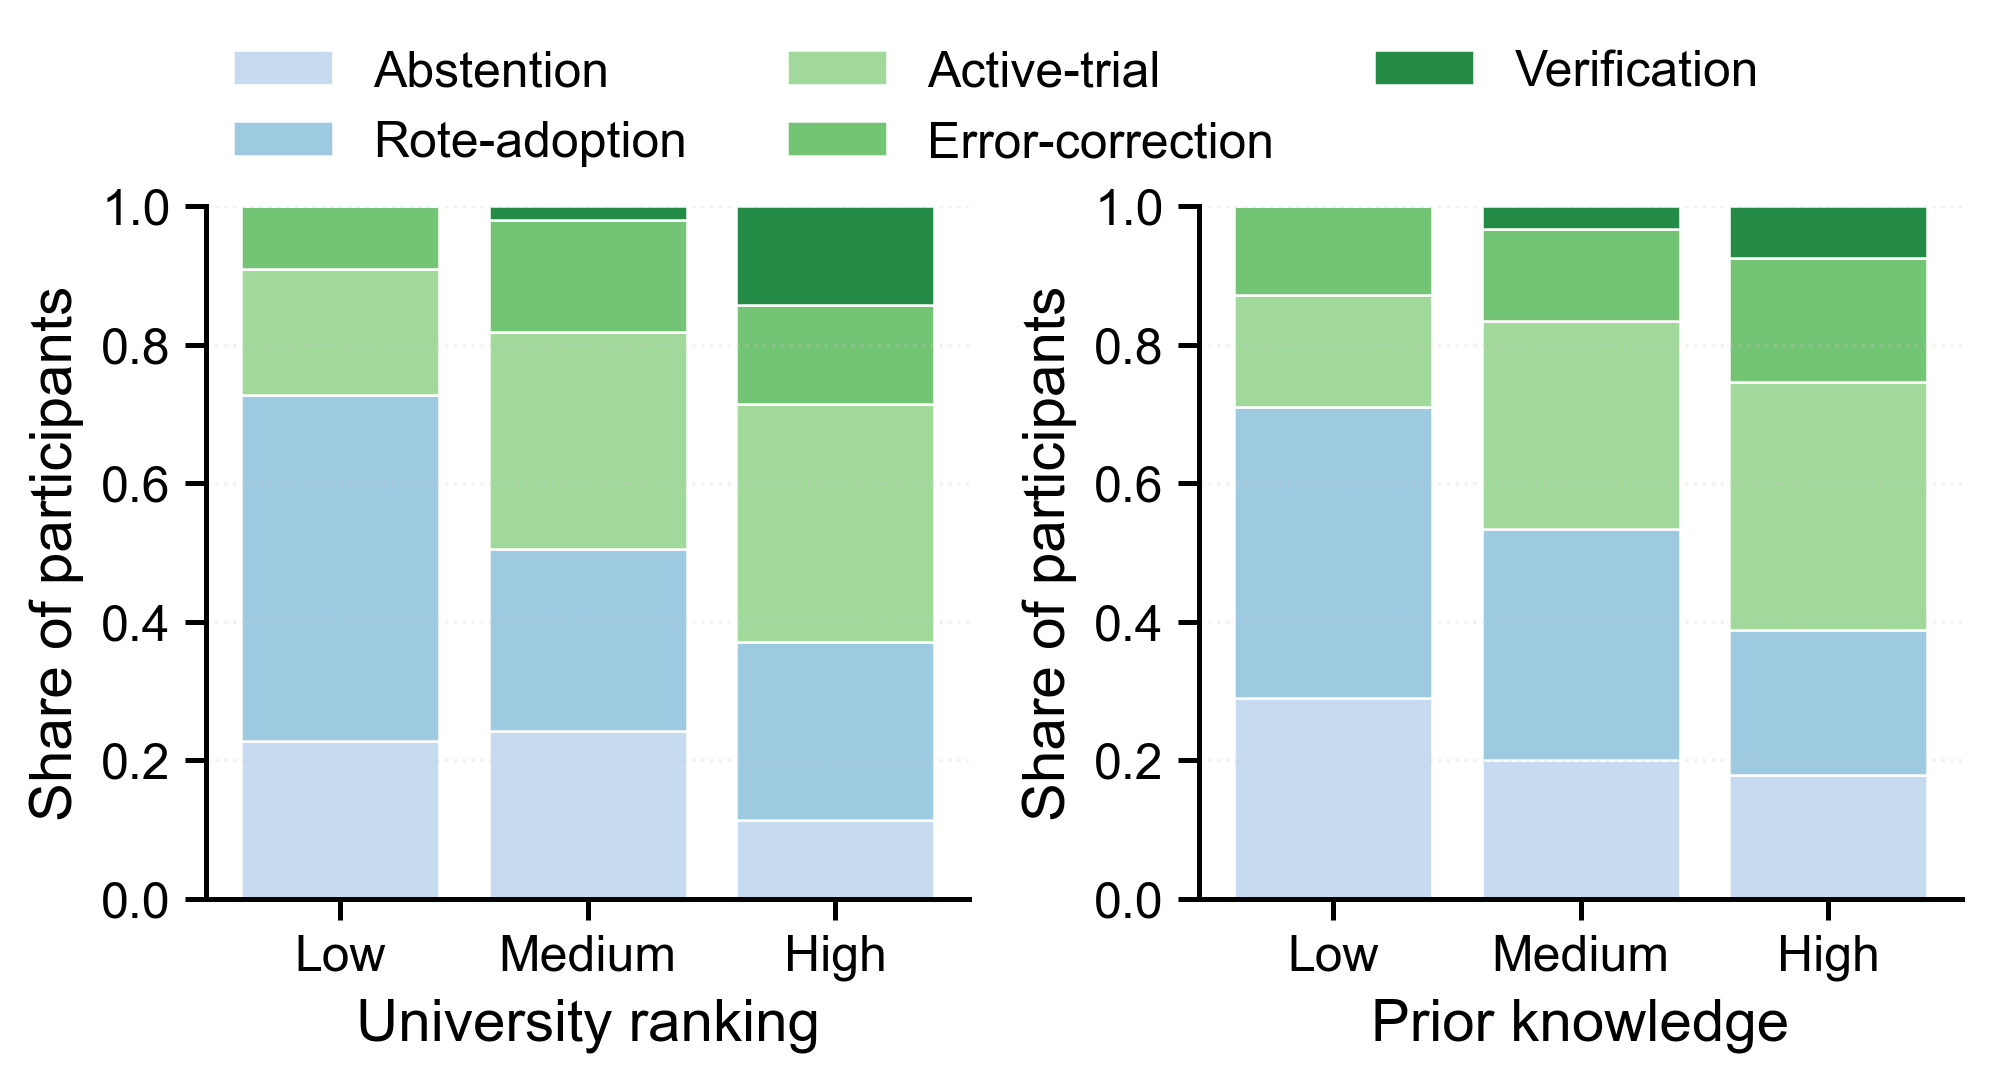

[A1 behavior] Saved behavior-group proportions plot to: a1_behavior_group_proportions_math_exp.pdf

[Behavior prediction] Python (Experiment only)
  Numeric encoding: university_cat={'Low': 1, 'Mid': 2, 'High': 3}, capability_cat={'Low': 1, 'Mid': 2, 'High': 3}
  University -> Behavior: coef=+0.1609 (p=0.127)
  Prior -> Behavior: coef=+0.2171 (p=0.0457) *
  University (Mid/High vs Low): Δp=+0.3207 (p=0.0353) * [p_low=0.111, p_mid_high=0.432]

[Behavior prediction] Math (Experiment only)
  Numeric encoding: university_cat={'Low': 1, 'Mid': 2, 'High': 3}, capability_cat={'Low': 1, 'Mid': 2, 'High': 3}
  University -> Behavior: coef=+0.1714 (p=0.0102) *
  Prior -> Behavior: coef=+0.1605 (p=0.00235) *
  University (Mid/High vs Low): Δp=+0.2571 (p=0.0127) * [p_low=0.273, p_mid_high=0.530]


In [4]:
# Attach a coarse behavior supergroup to each experimental participant.
# passive = abstention/rote-like behavior; proactive_critical = trial/verification/correction.
python_df = strata.add_behavior_supergroup_python(python_df)
math_df = strata.add_behavior_supergroup_math(math_df)

# Plot fine-grained profile composition within each background stratum.
python_behavior_out = FIGURES_DIR / "a1_behavior_group_proportions_python_exp.pdf"
math_behavior_out = FIGURES_DIR / "a1_behavior_group_proportions_math_exp.pdf"
inequality_plots.plot_python_a1_behavior_group_proportions(python_df, python_behavior_out, show=SHOW_FIGURES)
inequality_plots.plot_math_a1_behavior_group_proportions(math_df, math_behavior_out, show=SHOW_FIGURES)

# Quantify whether background strata predict proactive and critical behavior.
regression_stats.report_behavior_prediction_from_university_and_prior(python_df, "Python")
regression_stats.report_behavior_prediction_from_university_and_prior(math_df, "Math")


## Direct and Indirect Associations Through Learning Behavior

The behavior-adjusted OLS model provides the direct association \(c'\): the learner-profile coefficient after adding behavior profile to the score model. The coefficient-shift output below reports this estimate together with the total association \(c\) and the percentage accounted for by behavior, calculated as \((c-c')/c\times100\%\).

To supplement that OLS result, the notebook estimates only the indirect association \(a\times b\), using 10,000 nonparametric bootstrap resamples for its percentile 95% confidence interval. This is a mediation-style associational estimate rather than a causal mediation effect.



[Coefficient shift] Python (Experiment only)
  Numeric encoding: university_cat={'Low': 1, 'Mid': 2, 'High': 3}, capability_cat={'Low': 1, 'Mid': 2, 'High': 3}
  University R^2: base=0.0909, full=0.2702, ΔR^2=+0.1794
  Prior R^2: base=0.1276, full=0.2834, ΔR^2=+0.1558
  University university_cat_num: base=+2.2346 (p=0.0283), full=+1.5523 (p=0.0965), Δ=-0.6823, accounted=30.5% [shrink, sig->ns]
  University significance shifts: sig->ns=1, ns->sig=0
  Prior capability_cat_num: base=+2.7533 (p=0.00864), full=+1.8810 (p=0.0556), Δ=-0.8723, accounted=31.7% [shrink, sig->ns]
  Prior significance shifts: sig->ns=1, ns->sig=0

[Coefficient shift] Math (Experiment only)
  Numeric encoding: university_cat={'Low': 1, 'Mid': 2, 'High': 3}, capability_cat={'Low': 1, 'Mid': 2, 'High': 3}
  University R^2: base=0.0754, full=0.1075, ΔR^2=+0.0321
  Prior R^2: base=0.0562, full=0.0885, ΔR^2=+0.0323
  University university_cat_num: base=+1.7652 (p=0.000524), full=+1.5236 (p=0.00282), Δ=-0.2416, accounte

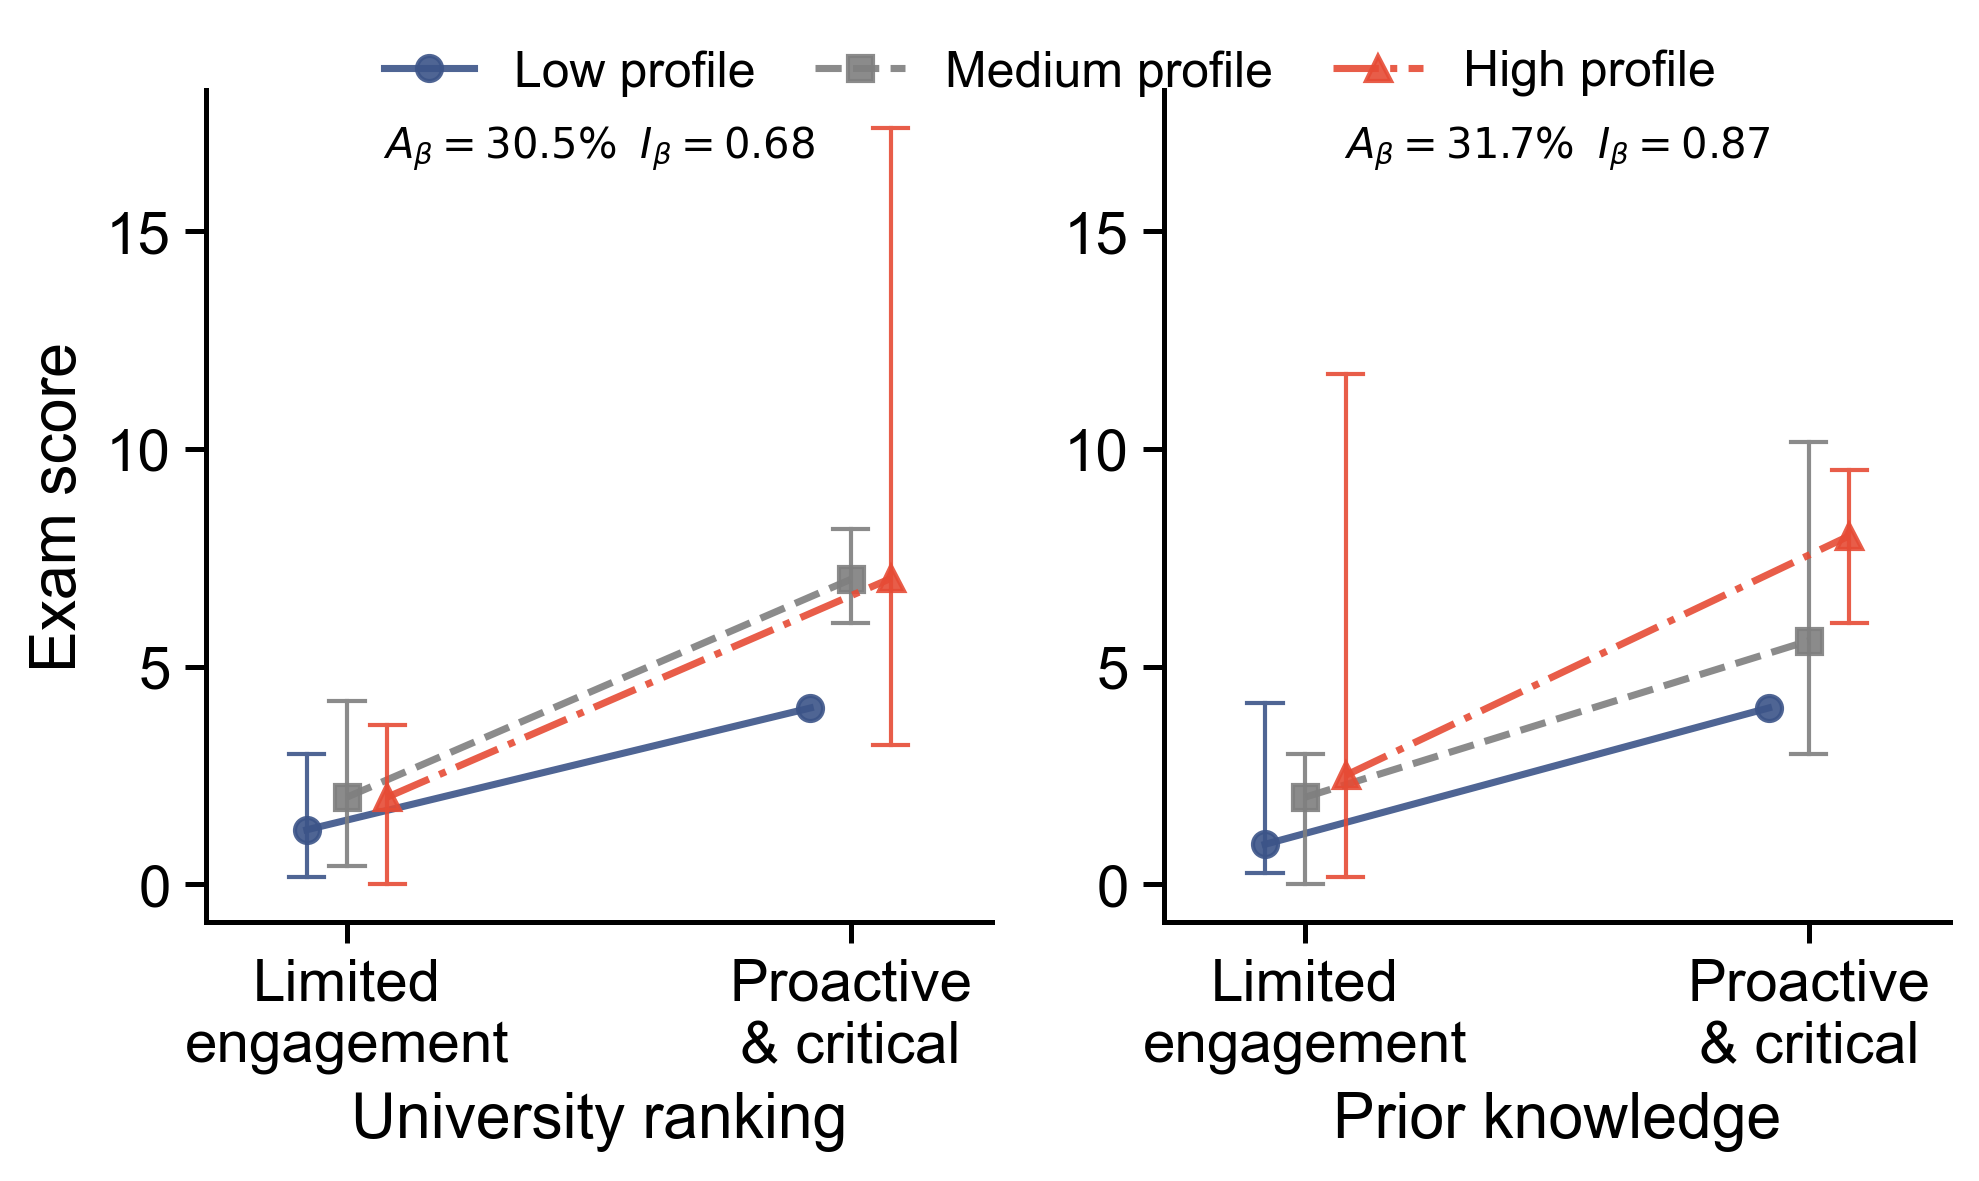

[Behavior equity] Saved combined plot to: inequal_behavior_combined_math.pdf


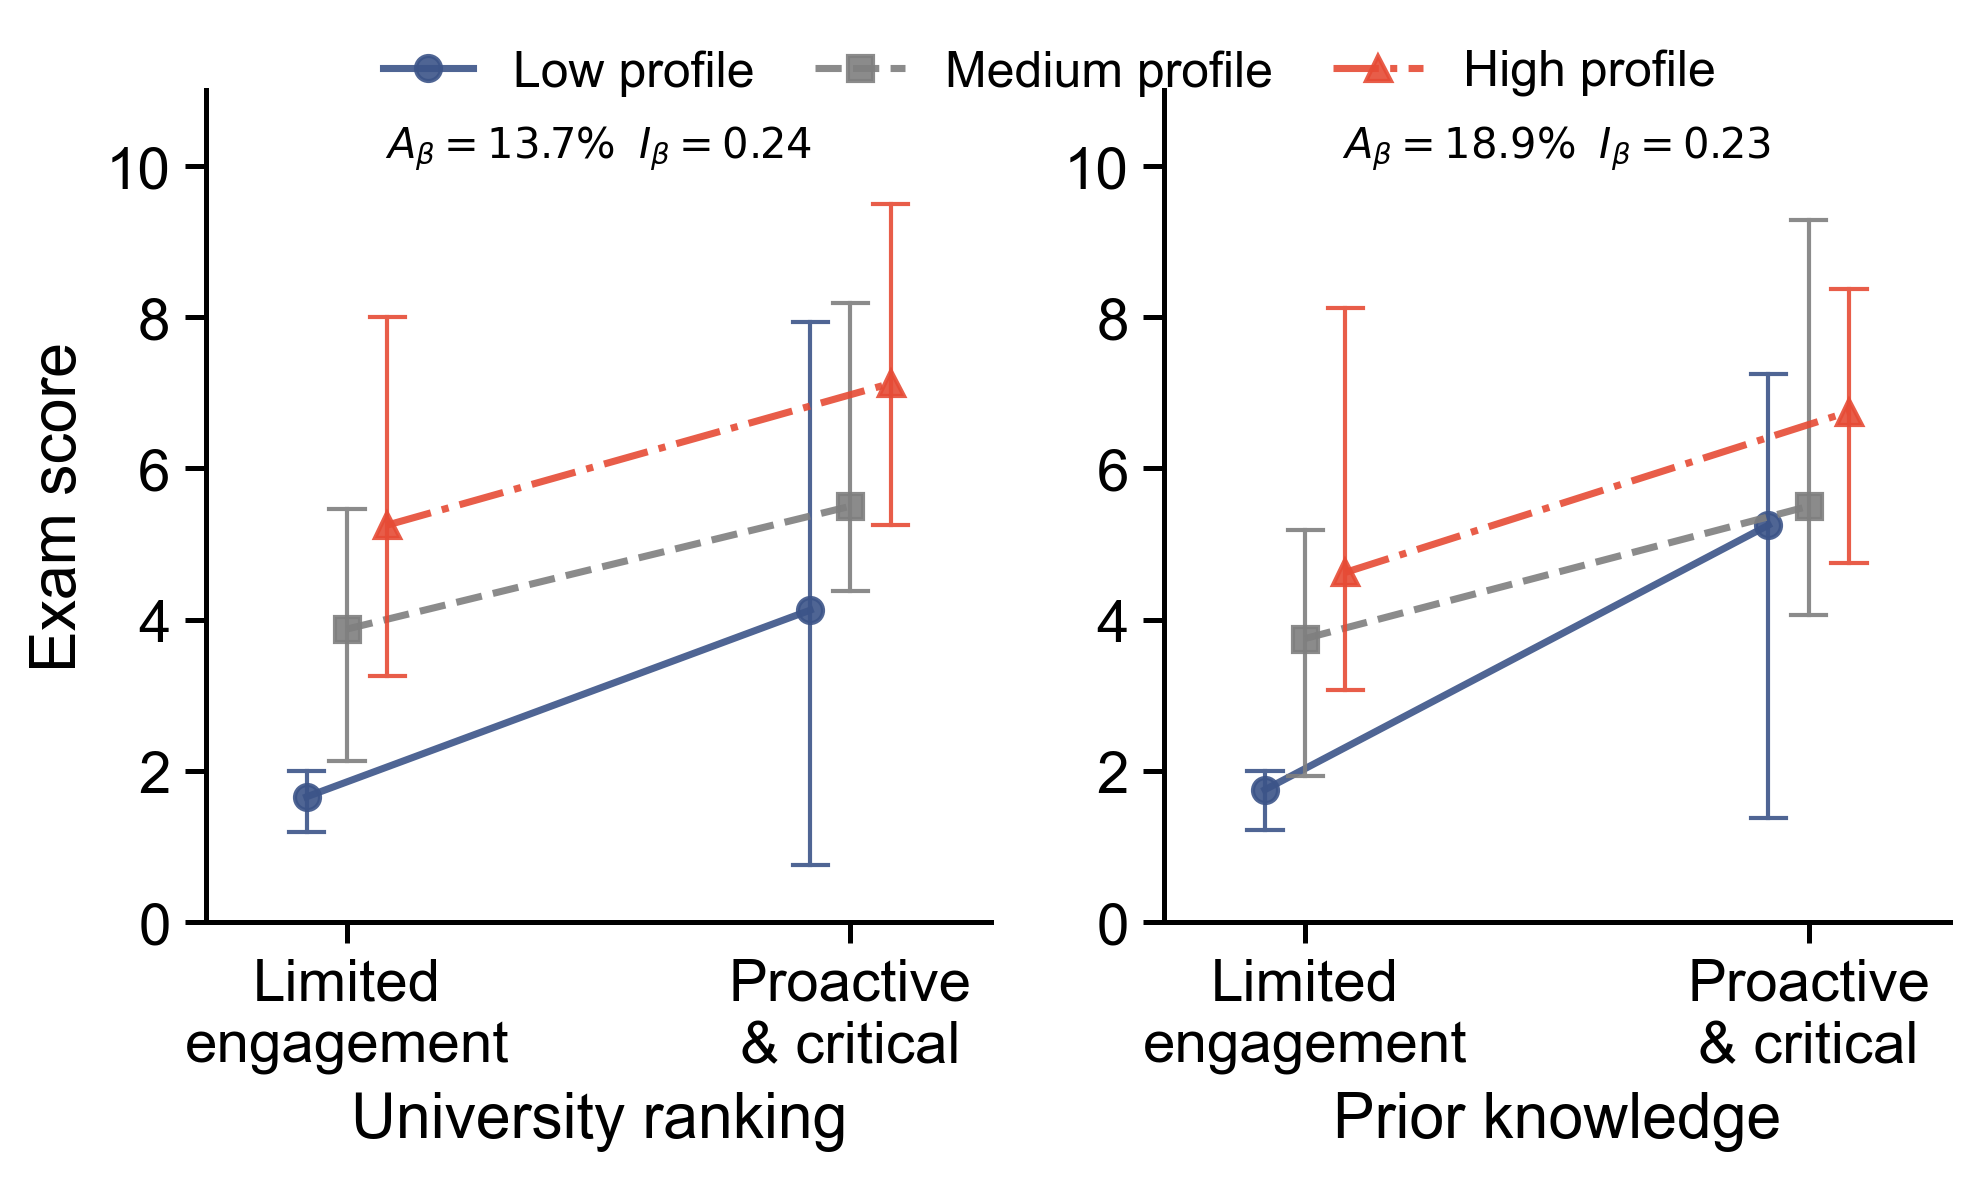

In [5]:
# Compute coefficient and R-squared changes after adding behavior profile.
python_ev_metrics = regression_stats.compute_explained_variance_behavior_metrics(python_df, "Python")
math_ev_metrics = regression_stats.compute_explained_variance_behavior_metrics(math_df, "Math")

regression_stats.report_explained_variance_behavior(python_df, "Python", metrics=python_ev_metrics)
regression_stats.report_explained_variance_behavior(math_df, "Math", metrics=math_ev_metrics)

# Bootstrap the indirect association a*b. The direct association c' is already
# reported by the behavior-adjusted OLS coefficient above.
python_indirect = regression_stats.compute_bootstrap_indirect_association_metrics(
    python_df, "Python", n_boot=10000, seed=42
)
math_indirect = regression_stats.compute_bootstrap_indirect_association_metrics(
    math_df, "Math", n_boot=10000, seed=43
)
regression_stats.report_bootstrap_indirect_association(python_indirect, "Python")
regression_stats.report_bootstrap_indirect_association(math_indirect, "Math")

indirect_results = pd.concat(
    [result for result in [python_indirect, math_indirect] if result is not None],
    ignore_index=True,
)
indirect_results

# Visualize behavior-conditioned median scores by background profile.
inequality_plots.plot_behavior_vs_exp_lines_combined(
    df=python_df,
    course_name="Python",
    proactive_critical_color="#31a354",
    passive_color="#7f7f7f",
    output_path=FIGURES_DIR / "inequal_behavior_combined_python.pdf",
    show=SHOW_FIGURES,
    explained_metrics=python_ev_metrics,
    indirect_metrics=python_indirect,
)
inequality_plots.plot_behavior_vs_exp_lines_combined(
    df=math_df,
    course_name="Math",
    proactive_critical_color="#31a354",
    passive_color="#7f7f7f",
    output_path=FIGURES_DIR / "inequal_behavior_combined_math.pdf",
    show=SHOW_FIGURES,
    explained_metrics=math_ev_metrics,
    indirect_metrics=math_indirect,
)


## Experimental-Control Score Differences by Background

This block compares exam scores between experimental and control groups within each background stratum. Interaction models estimate whether the experimental-control score difference changes with university ranking or prior knowledge.

The resulting estimates show whether score gaps across background groups become larger or smaller when comparing students with and without AI access.


  Python University rank: slope_control=+1.1030, slope_experiment=+2.2346
    interaction a3=+1.1317, p=0.463504
  Python Prior knowledge: slope_control=+1.6939, slope_experiment=+2.7479
    interaction a3=+1.0540, p=0.511332
  Math University rank: slope_control=+1.6364, slope_experiment=+1.7652
    interaction a3=+0.1288, p=0.882221
  Math Prior knowledge: slope_control=+1.1308, slope_experiment=+1.1582
    interaction a3=+0.0274, p=0.96932

Generating unweighted equity analysis plot for hw2_score...

Mean Statistics:

Python Course:

  :
university_cat  Control_Mean  Control_CI_Low  Control_CI_High  Control_N  Treatment_Mean  Treatment_CI_Low  Treatment_CI_High  Treatment_N       Gap
          High      5.226070        3.126852         7.338624          9        6.295504          2.940623          10.228793           13  1.069434
           Low      2.800000        0.600000         5.400000          5        1.690476          0.777778           2.645503            9 -1.109524
      

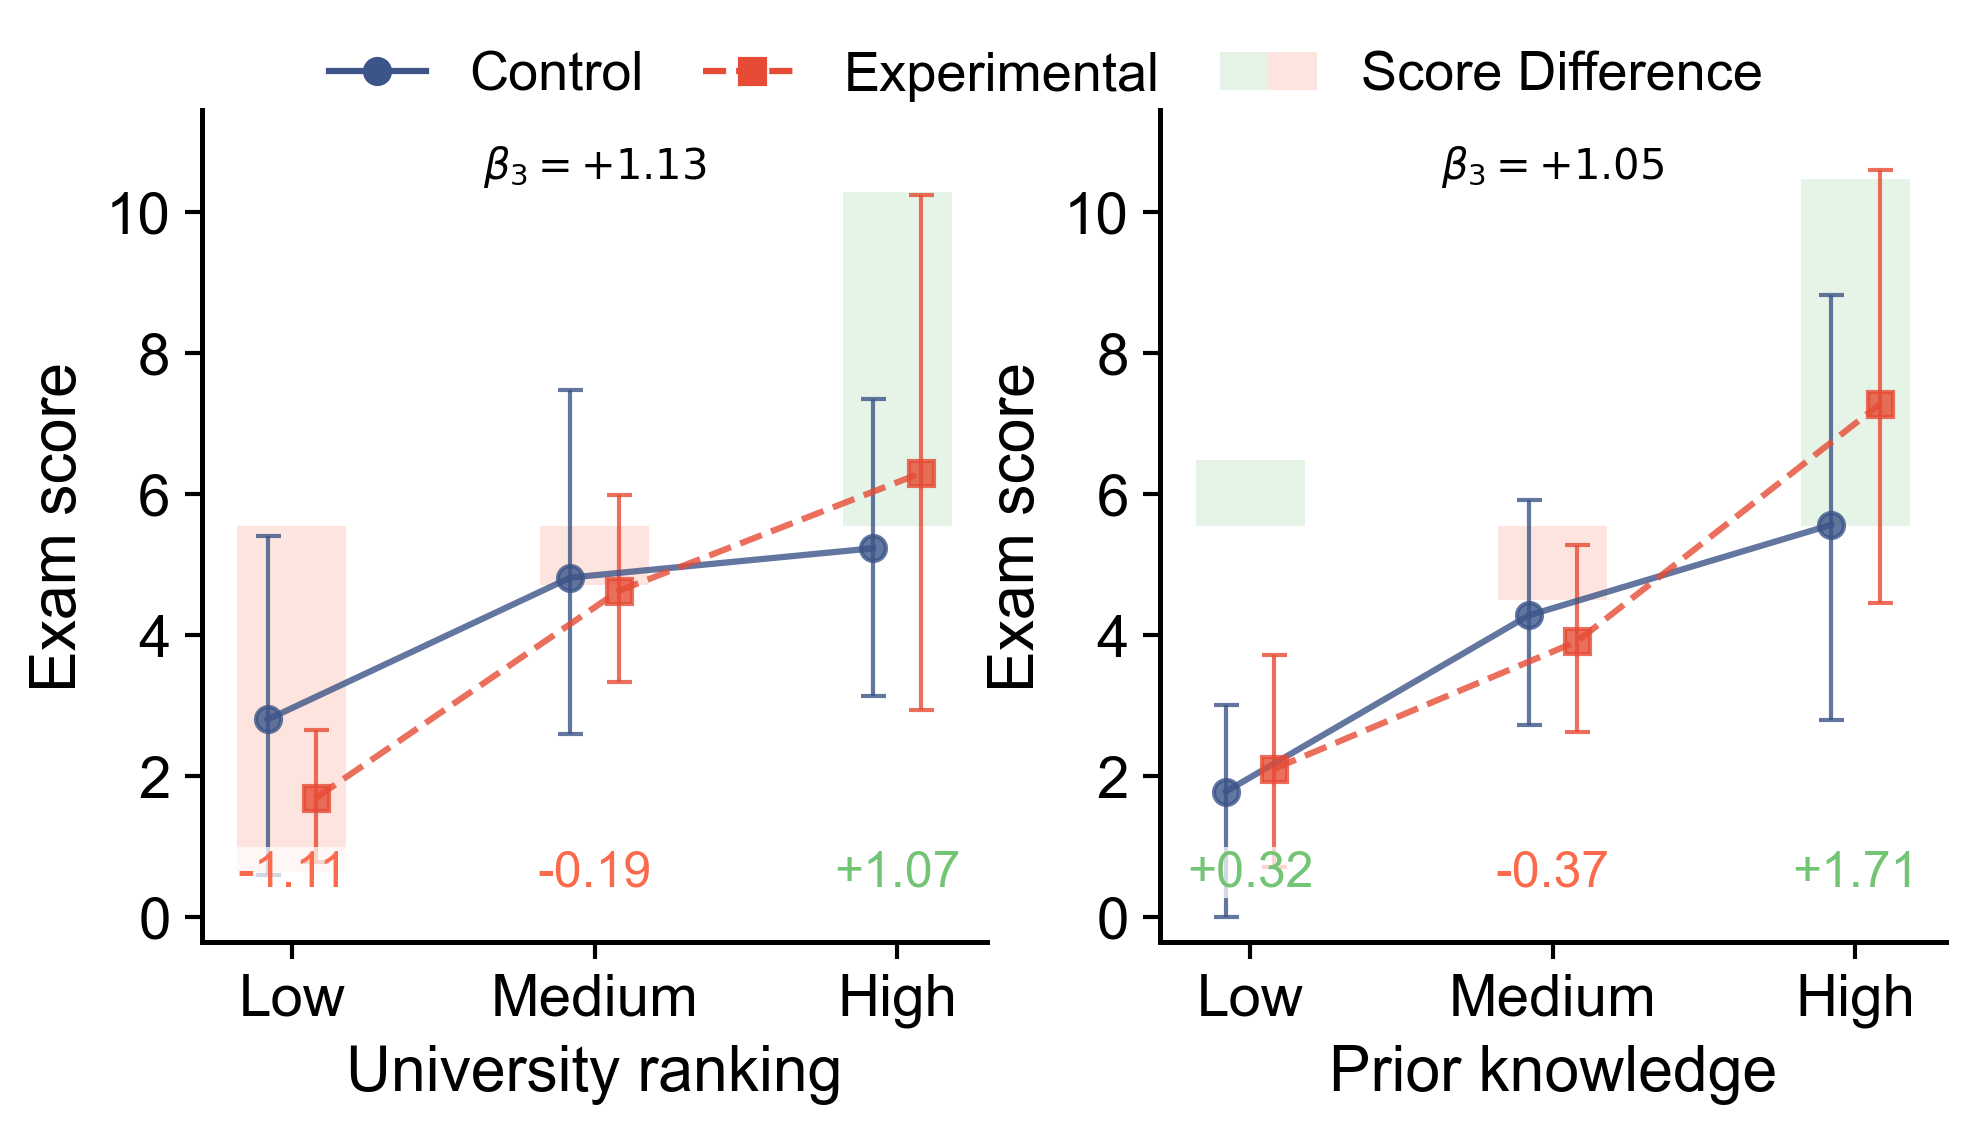


Saved unweighted plot to: inequal_unweighted_game_theory.pdf


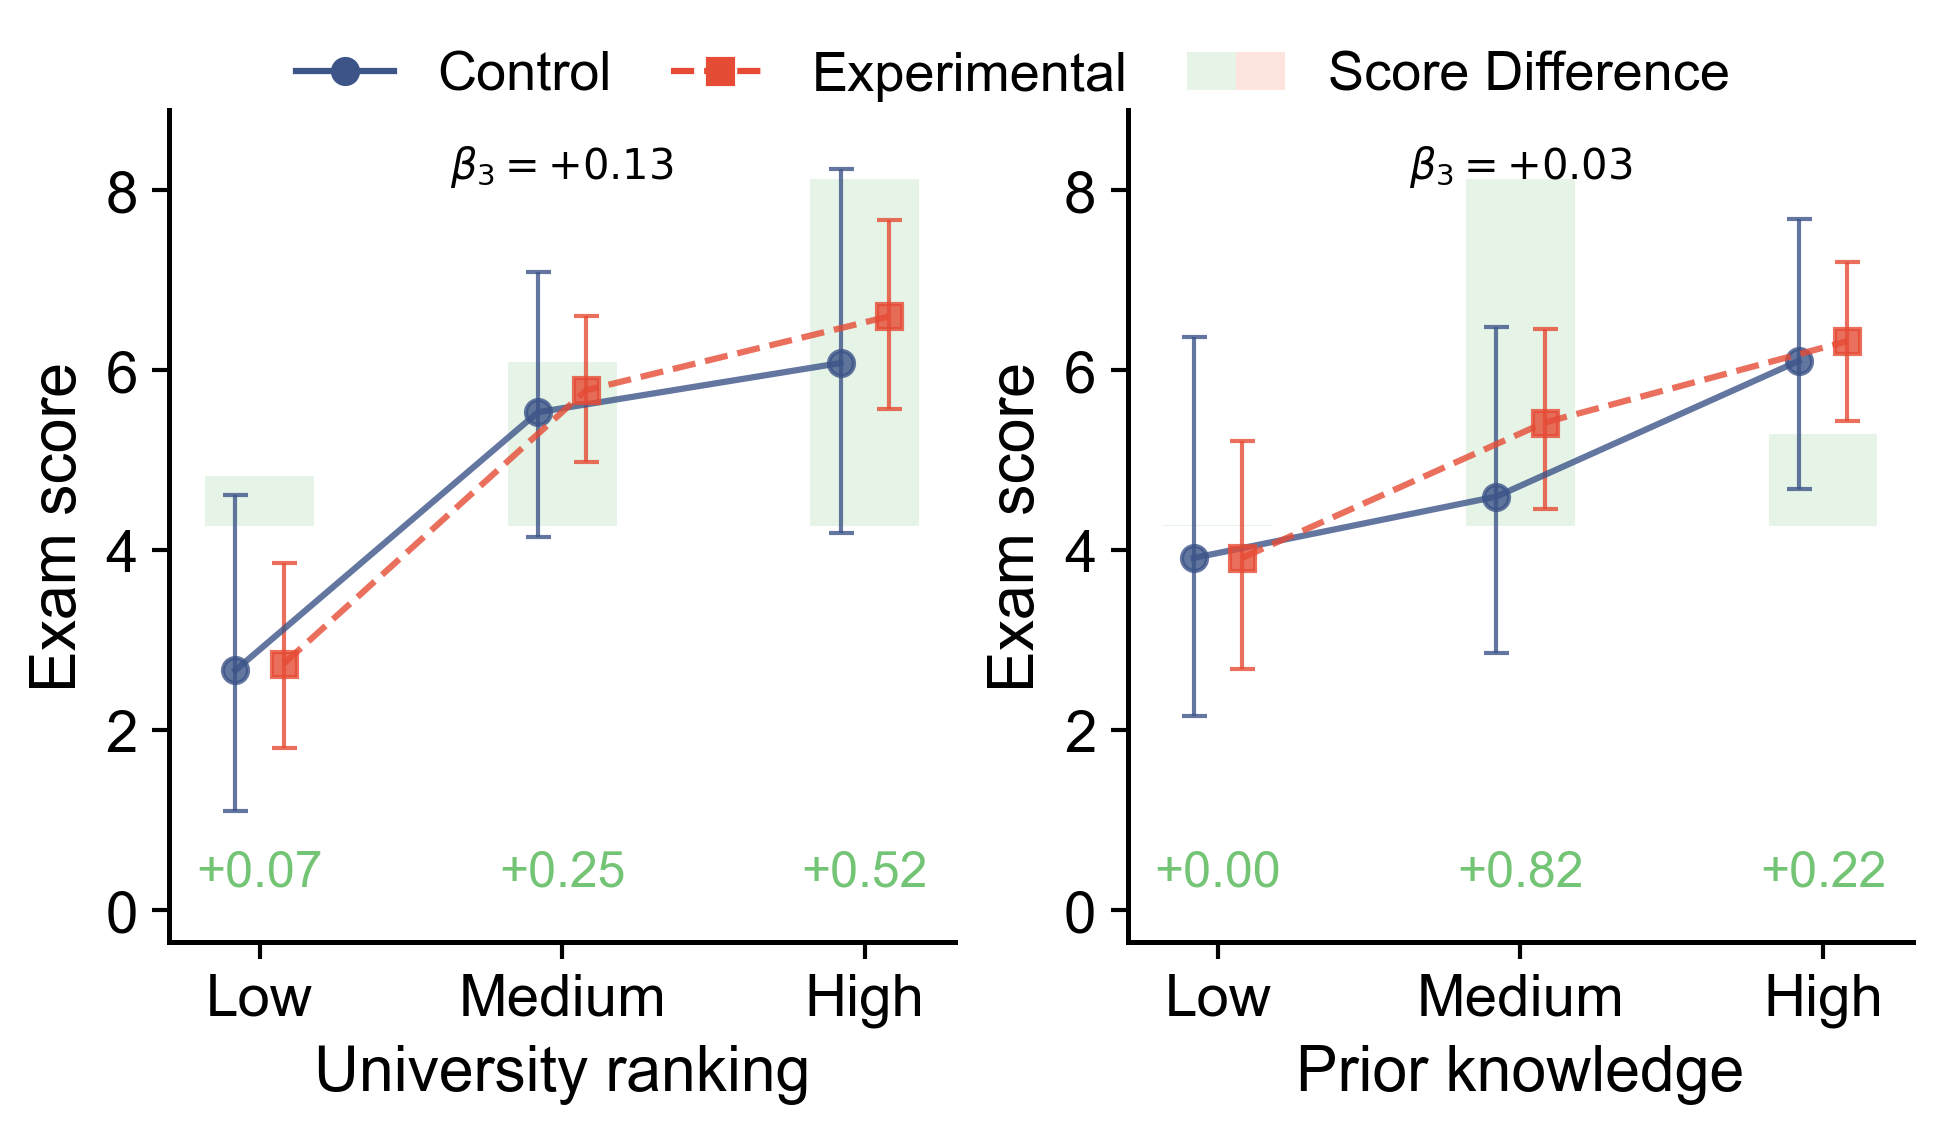

In [6]:
# Interaction tests: a positive interaction means the experimental-control
# difference is larger in higher background strata.
regression_stats.run_binned_numeric_model(python_df, "university_cat", "Python University rank")
regression_stats.run_binned_numeric_model(python_df, "capability_cat", "Python Prior knowledge")
regression_stats.run_binned_numeric_model(math_df, "university_cat", "Math University rank")
regression_stats.run_binned_numeric_model(math_df, "capability_cat", "Math Prior knowledge")

# Draw per-course experimental-control gaps across university and prior-knowledge strata.
inequality_plots.plot_equity(
    python_df,
    math_df,
    FIGURES_DIR / "inequal_unweighted.pdf",
    show=SHOW_FIGURES,
)


## Outputs

The notebook writes behavior-composition plots, behavior-adjusted score-gradient plots, and experimental-control score-gap plots for the two courses.
